In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense


# Load your dataset


# Replace 'path/to/your/dataset.csv' with the actual path to your dataset file


file_path = 'indiancrop_datasetwith_via.xlsx'


df = pd.read_excel(file_path)

In [2]:
df.head()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP,DESTINATION,DISTANCE,VIA1,VIA2,VIA3
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Andaman and Nicobar,7000,Rice,Andhra Pradesh,2150,Port Blair,Chennai,Visakhapatnam
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Andaman and Nicobar,5000,Rice,Andhra Pradesh,1780,Port Blair,Chennai,Vijayawada
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Andaman and Nicobar,7000,Rice,Tamil Nadu,1700,Port Blair,Chennai,Madurai
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Andaman and Nicobar,7000,Rice,West Bengal,2700,Port Blair,Chennai,Kolkata
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Andaman and Nicobar,120000,Rice,Andhra Pradesh,1780,Port Blair,Chennai,Vijayawada


In [3]:
df.tail()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP,DESTINATION,DISTANCE,VIA1,VIA2,VIA3
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,West Bengal,1000,Coffee,Odisha,490,Kolkata,Kharagpur,Bhubaneswar
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,West Bengal,800,Coffee,Odisha,490,Kolkata,Kharagpur,Bhubaneswar
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,West Bengal,560,Coffee,Odisha,490,Kolkata,Kharagpur,Bhubaneswar
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,West Bengal,1500,Coffee,Odisha,490,Kolkata,Kharagpur,Bhubaneswar
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,West Bengal,1400,Coffee,Odisha,490,Kolkata,Kharagpur,Bhubaneswar


In [4]:
df.isnull().sum()

N_SOIL         0
P_SOIL         0
K_SOIL         0
TEMPERATURE    0
HUMIDITY       0
ph             0
RAINFALL       0
STATE          0
CROP_PRICE     0
CROP           0
DESTINATION    0
DISTANCE       0
VIA1           0
VIA2           0
VIA3           0
dtype: int64

In [5]:

X = df[['N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']]
y = df['CROP']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
def rf(test_data):
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred)
    print("random forest")

    print("Accuracy: {:.2%}".format(accuracy))
    # print("Classification Report:\n", report)
    df_test = pd.DataFrame(test_data)
    predictions = rf_model.predict(df_test)
    print("Predicted Crop:", predictions)
    return predictions[0]

In [7]:
def nav(test_data):
    nb_model = GaussianNB()
    nb_model.fit(X_train, y_train)
    y_pred = nb_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print("naive_bayes")
    print("Accuracy: {:.2%}".format(accuracy))
    # print("Classification Report:\n", report)
    df_test = pd.DataFrame(test_data)
    predictions = nb_model.predict(df_test)

    print("Predicted Crop:", predictions)
    return predictions[0]

In [8]:
def dt(test_data):
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print("DecisionTree")
    print("Accuracy: {:.2%}".format(accuracy))
    # print("Classification Report:\n", report)
    df_test = pd.DataFrame(test_data)
    predictions = dt_model.predict(df_test)
    print("Predicted Crop:", predictions)
    return predictions[0]

In [9]:


def knn(test_data, k_neighbors=3):
    knn_model = KNeighborsClassifier(n_neighbors=k_neighbors)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print("knn")
    print("Accuracy: {:.2%}".format(accuracy))
    # print("Classification Report:\n", report)

    df_test = pd.DataFrame(test_data)
    predictions = knn_model.predict(df_test)

    print("Predicted Crop:", predictions)
    return predictions[0]

In [10]:

def ltsm(N_SOIL, P_SOIL, K_SOIL, TEMPERATURE, HUMIDITY, ph, RAINFALL):
    # Load the dataset
    data = pd.read_excel('indiancrop_datasetwith_via.xlsx')

    data = data[['N_SOIL', 'P_SOIL', 'K_SOIL',
                'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'CROP']]

    print(data.head())
    # Extract features and labels

    features = data.iloc[:, :-1].values
    labels = data.iloc[:, -1].values

    # Use LabelEncoder to convert string labels to numerical labels
    label_encoder = LabelEncoder()
    labels_encoded = label_encoder.fit_transform(labels)

    # Normalize features
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit the scaler on the training features
    features_scaled = scaler.fit_transform(features)
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features_scaled, labels_encoded, test_size=0.2, random_state=42)

    # Reshape input to be [samples, time steps, features]
    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    # Build LSTM Model
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True,
                   input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units=50))
    model.add(Dense(units=len(np.unique(labels)), activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_data=(X_test, y_test))

    # Example new data point for prediction with 6 features
    # Replace with your actual values
    new_data_point = np.array(
        [[N_SOIL, P_SOIL, K_SOIL, TEMPERATURE, HUMIDITY, ph, RAINFALL]])
    # new_data_point = np.array([[80, 50, 42, 22.5, 75.0, 6.8, 3]])

    # Normalize the new data using the fitted scaler
    new_data_scaled = scaler.transform(new_data_point)

    # Reshape the new data for LSTM input
    new_data_reshaped = np.reshape(
        new_data_scaled, (1, 1, new_data_scaled.shape[1]))

    # Make prediction
    prediction = model.predict(new_data_reshaped)

    # Decode the predicted label
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])

    print("Predicted Crop:", predicted_label[0])
    return predicted_label[0]


# ltsm(80, 50, 42, 22.5, 75.0, 6.8, 3)

In [11]:
# Ant colony
def antcol(desired_state, desired_crop):
    print("working")
    file_path = 'indiancrop_datasetwith_via.xlsx'
    df = pd.read_excel(file_path)
    selected_columns = ['STATE', 'CROP_PRICE', 'CROP',
                        'DESTINATION', 'DISTANCE', "VIA1", "VIA2", "VIA3"]
    filtered_df = df[selected_columns]
    filtered_df = df.loc[(df['STATE'] == desired_state) & (
        df['CROP'] == desired_crop), selected_columns]
    result_df = filtered_df.groupby(['STATE', 'DESTINATION', "DISTANCE",
                                    "CROP", "VIA1", "VIA2", "VIA3"], as_index=False)['CROP_PRICE'].mean()
    data = result_df
    np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T
    n_ants = 5
    n_iterations = 100
    decay = 0.6
    alpha = 1.0
    beta = 2.0
    pheromone = np.ones(len(np_data))
    best_solution_index = -1
    best_solution_distance = float('inf')
    best_solution_price = float('inf')
    best_solution_vias = []
    for i in range(n_iterations):
        ants = np.zeros((n_ants, len(np_data)), dtype=int)
        for ant in range(n_ants):
            for j in range(len(np_data)):
                choices = np.delete(np.arange(len(np_data)), ants[ant, :j])
                probabilities = (pheromone[choices] ** alpha) * \
                    ((1.0 / np_data[choices][:, 1]) ** beta)
                probabilities /= probabilities.sum()
                selected_index = np.random.choice(choices, p=probabilities)
                ants[ant, j] = selected_index
        pheromone *= (1.0 - decay)
        for ant in range(n_ants):
            for j in range(len(np_data) - 1):
                pheromone[ants[ant, j]] += 1.0 / np_data[ants[ant, j], 0]
        min_distance_index = np.argmin(np_data[:, 1])
        current_solution_distance = np_data[min_distance_index, 1]
        current_solution_price = np_data[min_distance_index, 0]
        if current_solution_distance < best_solution_distance:
            best_solution_distance = current_solution_distance
            best_solution_price = current_solution_price
            best_solution_index = min_distance_index
            best_solution_vias = data.loc[best_solution_index, [
                "VIA1", "VIA2", "VIA3"]].values.tolist()
    s={"desired_state":desired_state,
                "designation":data.loc[best_solution_index, "DESTINATION"],
                "Distance":best_solution_distance,
                "price":best_solution_price,
                "Vias":best_solution_vias}
    
    return s

In [12]:
# artifical bee colony
def artibeecol(desired_state, desired_crop):
    s=[]
    file_path = 'indiancrop_datasetwith_via.xlsx'
    df = pd.read_excel(file_path)
    selected_columns = ['STATE', 'CROP_PRICE', 'CROP',
                        'DESTINATION', 'DISTANCE', "VIA1", "VIA2", "VIA3"]
    filtered_df = df[selected_columns]
    # desired_state = 'Gujarat'
    # desired_crop = 'Maize'
    filtered_df = df.loc[(df['STATE'] == desired_state) & (
        df['CROP'] == desired_crop), selected_columns]
    result_df = filtered_df.groupby(['STATE', 'DESTINATION', "DISTANCE",
                                    "CROP", "VIA1", "VIA2", "VIA3"], as_index=False)['CROP_PRICE'].mean()
    data = result_df
    np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T
    n_bees = 5
    n_iterations = 100
    limit = 100
    lower_bound = 0
    upper_bound = len(np_data)
    best_solution_index = -1
    best_solution_distance = float('inf')
    best_solution_price = float('inf')
    best_solution_vias = []
    for iteration in range(n_iterations):
        for bee in range(n_bees):
            current_solution_index = np.random.randint(
                lower_bound, upper_bound)
            current_solution_distance = np_data[current_solution_index, 1]
            current_solution_price = np_data[current_solution_index, 0]
            if current_solution_distance < best_solution_distance:
                best_solution_distance = current_solution_distance
                best_solution_price = current_solution_price
                best_solution_index = current_solution_index
                best_solution_vias = data.loc[best_solution_index, [
                    "VIA1", "VIA2", "VIA3"]].values.tolist()
        if np.random.rand() < 1.0 / (1 + best_solution_distance):
            best_solution_index = np.random.randint(lower_bound, upper_bound)
            best_solution_distance = np_data[best_solution_index, 1]
            best_solution_price = np_data[best_solution_index, 0]
            best_solution_vias = data.loc[best_solution_index, [
                "VIA1", "VIA2", "VIA3"]].values.tolist()
        # print(f"Iteration {iteration + 1}/{n_iterations}: Best Distance = {best_solution_distance}, Best Price = {best_solution_price}")
        
    s={"desired_state":desired_state,
                       "designation":data.loc[best_solution_index, "DESTINATION"],
                       "Distance":best_solution_distance,
                       "price":best_solution_price,
                       "Vias":best_solution_vias}
    
    return s

In [13]:
def simulated_annealing(desired_state, desired_crop, initial_temperature=1000, cooling_rate=0.95, n_iterations=100):
    s=[]
    print(desired_state, desired_crop)
    file_path = 'indiancrop_datasetwith_via.xlsx'
    df = pd.read_excel(file_path)
    selected_columns = ['STATE', 'CROP_PRICE', 'CROP',
                        'DESTINATION', 'DISTANCE', "VIA1", "VIA2", "VIA3"]
    filtered_df = df[selected_columns]

    filtered_df = df.loc[(df['STATE'] == desired_state) & (
        df['CROP'] == desired_crop), selected_columns]

    result_df = filtered_df.groupby(['STATE', 'DESTINATION', "DISTANCE",
                                    "CROP", "VIA1", "VIA2", "VIA3"], as_index=False)['CROP_PRICE'].mean()

    data = result_df
    np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

    current_solution_index = np.random.randint(0, len(np_data))
    current_solution_distance = np_data[current_solution_index, 1]
    current_solution_price = np_data[current_solution_index, 0]
    current_solution_vias = data.loc[current_solution_index, [
        "VIA1", "VIA2", "VIA3"]].values.tolist()

    best_solution_index = current_solution_index
    best_solution_distance = current_solution_distance
    best_solution_price = current_solution_price
    best_solution_vias = current_solution_vias

    temperature = initial_temperature

    for iteration in range(n_iterations):
        neighbor_index = np.random.randint(0, len(np_data))
        neighbor_distance = np_data[neighbor_index, 1]
        neighbor_price = np_data[neighbor_index, 0]
        neighbor_vias = data.loc[neighbor_index, [
            "VIA1", "VIA2", "VIA3"]].values.tolist()

        if neighbor_distance < current_solution_distance or np.random.rand() < np.exp((current_solution_distance - neighbor_distance) / temperature):
            current_solution_index = neighbor_index
            current_solution_distance = neighbor_distance
            current_solution_price = neighbor_price
            current_solution_vias = neighbor_vias

        if current_solution_distance < best_solution_distance:
            best_solution_index = current_solution_index
            best_solution_distance = current_solution_distance
            best_solution_price = current_solution_price
            best_solution_vias = current_solution_vias

        temperature *= cooling_rate
    s={"source":desired_state,
        "desired_state":desired_state,
                       "designation":data.loc[best_solution_index, "DESTINATION"],
                       "Distance":best_solution_distance,
                       "price":best_solution_price,
                       "Vias":best_solution_vias}

    
    return s

In [14]:

# (80, 50, 42, 22.5, 75.0, 6.8, 3)
import pandas as pd
test_data = {
    'N_SOIL': [80],
    'P_SOIL': [50],
    'K_SOIL': [42],
    'TEMPERATURE': [22.5],
    'HUMIDITY': [75.0],
    'ph': [6.8],
    'RAINFALL': [3],
}


def get_source_states_for_crop(crop):
    file_path = 'indiancrop_datasetwith_via.xlsx'
    df = pd.read_excel(file_path)

    # Filter the data for the specified crop
    filtered_df = df[df['CROP'] == crop]

    # Get unique source states for the filtered crop
    source_states = filtered_df['STATE'].unique()

    return source_states


a = input("1. Random forest 2. naive_bayes 3.DecisionTree 4.knn 5.lstm")
if a == '1':
    crop = rf(test_data)
elif a == '2':
    crop = nav(test_data)
elif a == '3':
    crop = dt(test_data)
elif a == '4':
    crop = knn(test_data)
elif a == '5':
    crop = ltsm(test_data["N_SOIL"][0], test_data["P_SOIL"][0], test_data["K_SOIL"][0], test_data["TEMPERATURE"]
                [0], test_data['HUMIDITY'][0], test_data['ph'][0], test_data['RAINFALL'][0])


source_states = get_source_states_for_crop(crop)
b = input('1. simulated_annealing 2.artibeecol 3.antcol')
out=[]
for source in source_states:
    if b == '1':
        data=simulated_annealing(source, crop)
        out.append(data)
    elif b == '2':
        data=artibeecol(source, crop)
        print(data)
    elif b == '3':
        data=antcol(source, crop)
        print(data)
print(out)

1. Random forest 2. naive_bayes 3.DecisionTree 4.knn 5.lstm 1


random forest
Accuracy: 99.32%
Predicted Crop: ['Muskmelon']


1. simulated_annealing 2.artibeecol 3.antcol 1


Tamil Nadu Muskmelon
Telangana Muskmelon
Tripura Muskmelon
Uttar Pradesh Muskmelon
[{'source': 'Tamil Nadu', 'desired_state': 'Tamil Nadu', 'designation': 'Karnataka', 'Distance': 380.0, 'price': 3691.6666666666665, 'Vias': ['Madurai', 'Salem', 'Banglore']}, {'source': 'Telangana', 'desired_state': 'Telangana', 'designation': 'Andhra Pradesh', 'Distance': 325.0, 'price': 856.6666666666666, 'Vias': ['Hyderabad', 'Khammam', 'Vijayawada']}, {'source': 'Tripura', 'desired_state': 'Tripura', 'designation': 'Assam', 'Distance': 500.0, 'price': 4557.142857142857, 'Vias': ['Dharmanagar', 'Haflong', 'Silchar']}, {'source': 'Uttar Pradesh', 'desired_state': 'Uttar Pradesh', 'designation': 'Uttarakhand', 'Distance': 560.0, 'price': 909.0909090909091, 'Vias': ['Lucknow', 'Bareily', 'Dehradun']}]


In [19]:
import pandas as pd


def get_source_states_for_crop(crop):
    file_path = 'indiancrop_datasetwith_via.xlsx'
    df = pd.read_excel(file_path)

    # Filter the data for the specified crop
    filtered_df = df[df['CROP'] == crop]

    # Get unique source states for the filtered crop
    source_states = filtered_df['STATE'].unique()

    return source_states


# Example usage:
crop = "Muskmelon"
source_states = get_source_states_for_crop(crop)
print("Source States for", crop, ":", source_states)

Source States for Muskmelon : ['Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh']


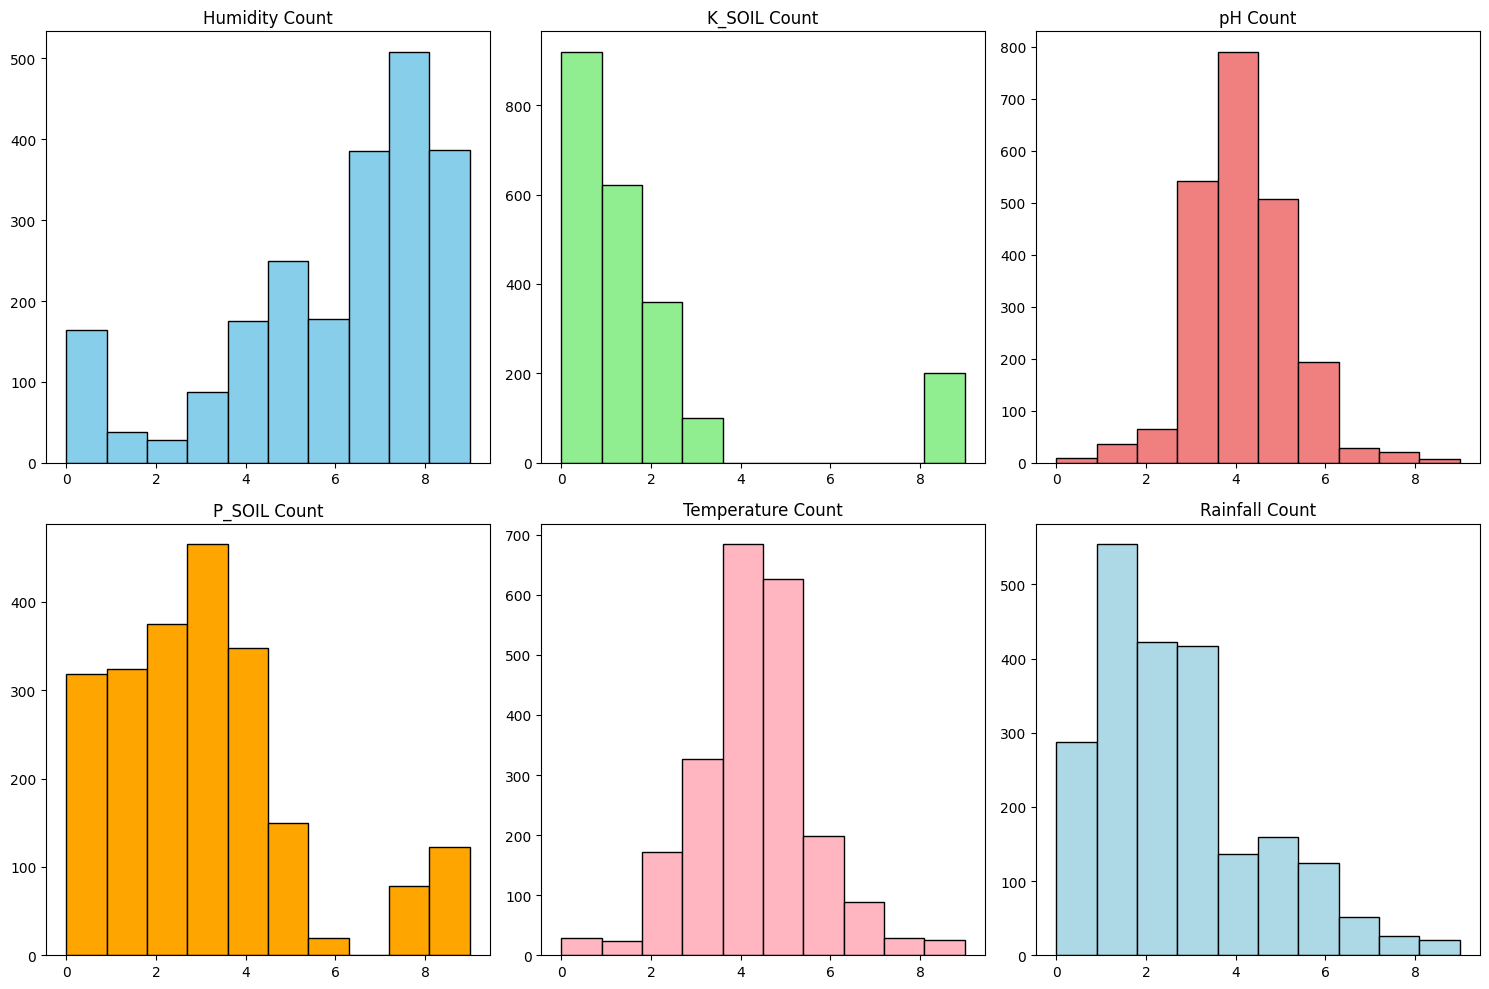

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is stored in a DataFrame named 'df'

# Discretize continuous variables into categories
humidity_bins = pd.cut(df['HUMIDITY'], bins=10, labels=False)
ksoil_bins = pd.cut(df['K_SOIL'], bins=10, labels=False)
ph_bins = pd.cut(df['ph'], bins=10, labels=False)
psoil_bins = pd.cut(df['P_SOIL'], bins=10, labels=False)
temperature_bins = pd.cut(df['TEMPERATURE'], bins=10, labels=False)
rainfall_bins = pd.cut(df['RAINFALL'], bins=10, labels=False)

# Create count plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(humidity_bins, bins=10, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Humidity Count')

axes[0, 1].hist(ksoil_bins, bins=10, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('K_SOIL Count')

axes[0, 2].hist(ph_bins, bins=10, color='lightcoral', edgecolor='black')
axes[0, 2].set_title('pH Count')

axes[1, 0].hist(psoil_bins, bins=10, color='orange', edgecolor='black')
axes[1, 0].set_title('P_SOIL Count')

axes[1, 1].hist(temperature_bins, bins=10,
                color='lightpink', edgecolor='black')
axes[1, 1].set_title('Temperature Count')

axes[1, 2].hist(rainfall_bins, bins=10, color='lightblue', edgecolor='black')
axes[1, 2].set_title('Rainfall Count')

plt.tight_layout()
plt.show()

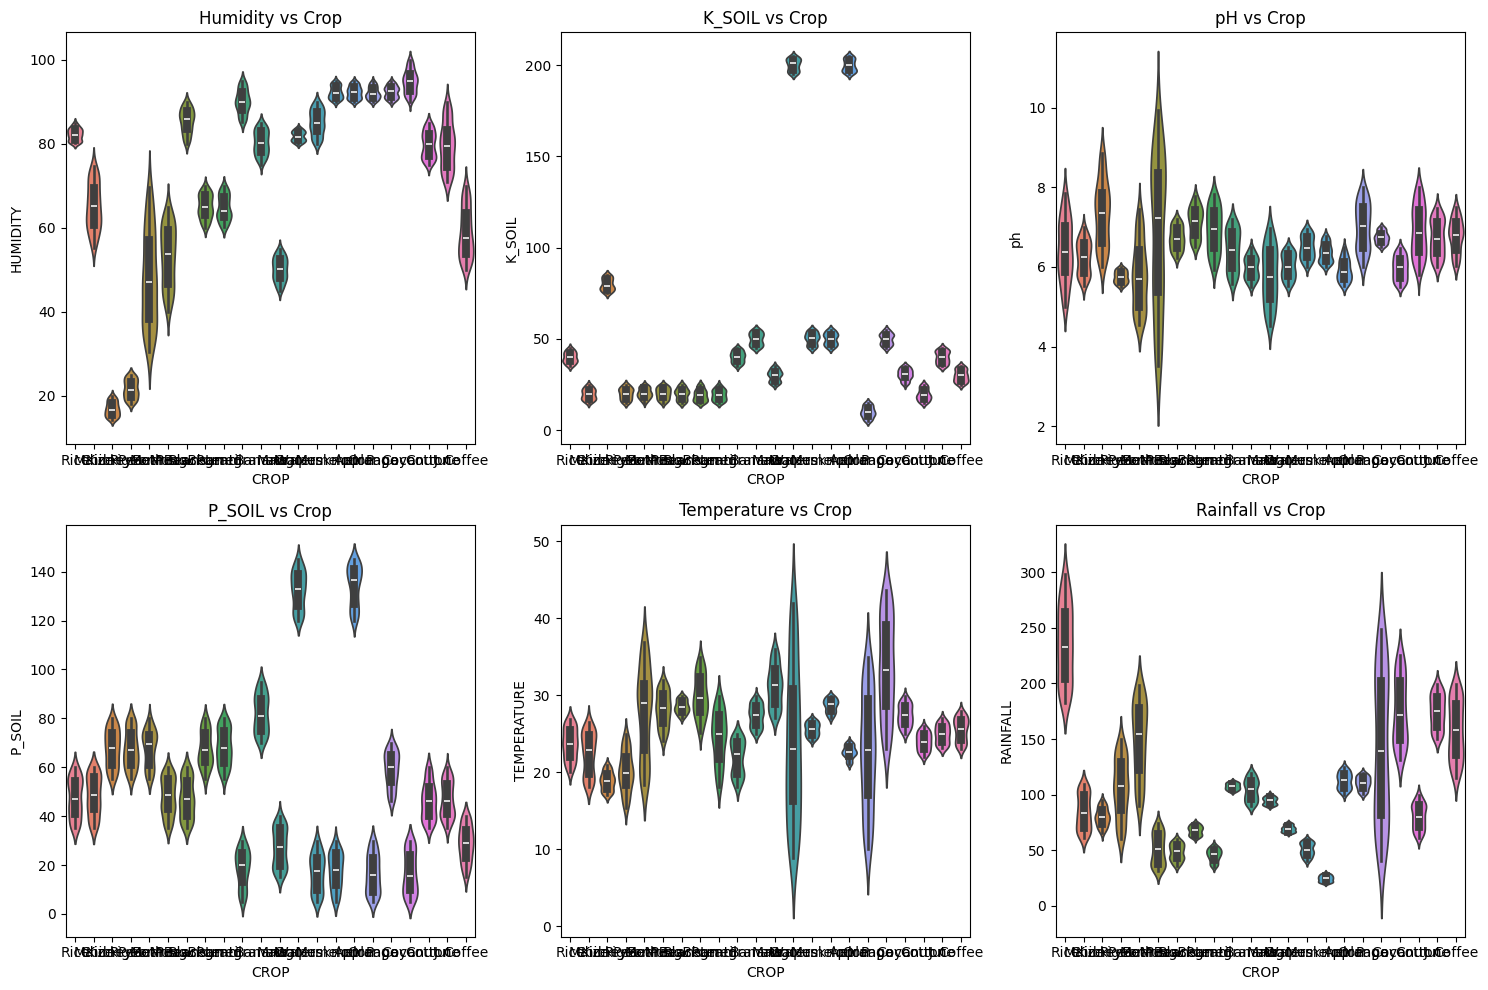

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is stored in a DataFrame named 'df'

# Set up the figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Get unique crop values from the 'CROP' column
unique_crops = df['CROP'].unique()

# Define colors for each crop
crop_colors = {crop: sns.color_palette("husl", n_colors=len(unique_crops))[
    i] for i, crop in enumerate(unique_crops)}

# Create violin plots for each combination with consistent colors for each crop
sns.violinplot(x='CROP', y='HUMIDITY', data=df, hue='CROP',
               palette=crop_colors, ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Humidity vs Crop')

sns.violinplot(x='CROP', y='K_SOIL', data=df, hue='CROP',
               palette=crop_colors, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('K_SOIL vs Crop')

sns.violinplot(x='CROP', y='ph', data=df, hue='CROP',
               palette=crop_colors, ax=axes[0, 2], legend=False)
axes[0, 2].set_title('pH vs Crop')

sns.violinplot(x='CROP', y='P_SOIL', data=df, hue='CROP',
               palette=crop_colors, ax=axes[1, 0], legend=False)
axes[1, 0].set_title('P_SOIL vs Crop')

sns.violinplot(x='CROP', y='TEMPERATURE', data=df, hue='CROP',
               palette=crop_colors, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Temperature vs Crop')

sns.violinplot(x='CROP', y='RAINFALL', data=df, hue='CROP',
               palette=crop_colors, ax=axes[1, 2], legend=False)
axes[1, 2].set_title('Rainfall vs Crop')

# Adjust layout
plt.tight_layout()
plt.show()